In [1]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from metpy.calc import wind_speed, wind_direction
from metpy.units import units

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [
    'Helvetica',
    'Nimbus Sans',
    'Arial',
    'Liberation Sans'
]

data_dir = '../data_out/'
fig_png_dir = '../figures_png/'
fig_pdf_dir = '../figures_pdf/'

In [2]:
def calc_wind(u,v):
    wspd = wind_speed(u * units("m/s"), v * units("m/s"))
    wdir = wind_direction(u * units("m/s"), v * units("m/s"))
    return wspd, wdir

## Script settings

In [3]:
# scope ='H2'
scope ='H3'

In [4]:
# do scope specific settings
if scope == 'H2':
    scope_name = 'HEFEX II'

    # obs data
    loc = 'T275'
    file = 'HEFEX2__Obs_AWS_L1__1h_avg30min_20230816-20230910.nc'
    file_era5 = data_dir + 'ECMWF_ERA5_hourly_wind_500hPa__20230801_20230930.nc'

    # time frame and shading
    dt_from,dt_to = '2023-08-17', '2023-09-07'
    shading = [['2023-08-20 00:00','2023-08-25 00:00'],
               ['2023-08-29 00:00','2023-08-30 00:00'],
               ['2023-09-04 00:00','2023-09-07 00:00']]
    shading_c = ['#d1ced0','#b5ded5','#d4ddf2']
elif scope == 'H3':
    scope_name = 'HEFEX III'

    # obs data
    loc = 'T272'
    file = 'HEFEX3__Obs_AWS_L1__1h_avg30min_20250805-20250903.nc'
    file_era5 = data_dir + 'ECMWF_ERA5_hourly_wind_500hPa__20250801_20250930.nc'

    # time frame and shading
    dt_from,dt_to = '2025-08-06', '2025-09-01'
    shading = [['2025-08-07 00:00','2025-08-10 12:00'],
               ['2025-08-10 00:00','2025-08-11 00:00']]
    shading_c = ['#d1ced0','#b5ded5']
else:
    print('Unknown scope!')

## Get observational data

In [5]:
ds = xr.open_dataset(data_dir + file).sel(location=loc)

ds_hr = pd.DataFrame()
ds_hr['time'] = pd.to_datetime(ds.time.values, utc=True)
ds_hr['t_2m'] = ds.t_2m.values
ds_hr['t_4m'] = ds.t_4m.values
ds_hr['rh_2m'] = ds.rh_2m.values
ds_hr['rh_4m'] = ds.rh_4m.values
ds_hr['pres'] = ds.pres.values
ds_hr.set_index('time', inplace=True)

ds_avg = pd.DataFrame()
ds_avg['time'] = pd.to_datetime(ds.time_avg.values, utc=True)
ds_avg['wspd'] = ds.wspd_avg.values
ds_avg['wdir'] = ds.wdir_avg.values
ds_avg.set_index('time', inplace=True)

lat,lon = ds.lat.values, ds.lon.values

ds.close()

In [6]:
ds = xr.open_dataset(file_era5).sel(lat=lat, lon=lon, method='nearest').sel(plev=50000)

df_pl = pd.DataFrame()
df_pl['time'] = pd.to_datetime(ds.time.values, utc=True)
df_pl['u'] = ds.u.values
df_pl['v'] = ds.v.values
df_pl['clc'] = ds.clc.values * 100
df_pl.set_index('time', inplace=True)

df_pl['wspd'], df_pl['wdir'] = calc_wind(df_pl['u'].values, df_pl['v'].values)

ds.close()

## Create plot

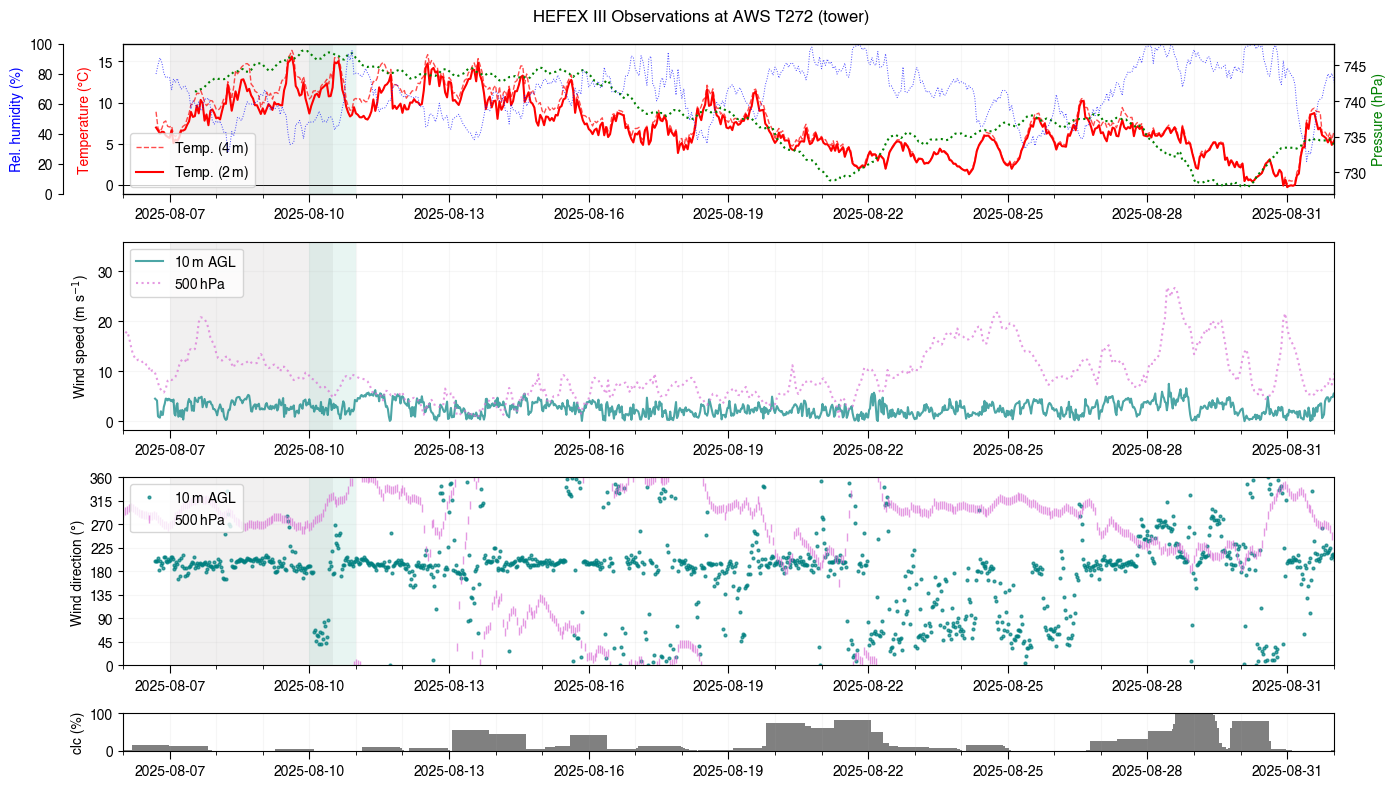

In [7]:
fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(14,8),gridspec_kw={'height_ratios': [1, 1.25, 1.25, .25]})

# temp
ax = axs[0]
ax.plot(ds_hr.index, ds_hr['t_4m'], c='red', label=r'Temp. (4$\,$m)', ls='--', lw=1, alpha=.7)
ax.plot(ds_hr.index, ds_hr['t_2m'], c='red', label=r'Temp. (2$\,$m)')
ax.axhline(0,c='black',zorder=-1, lw=.7)
ax.set_ylabel('Temperature (°C)', color='red')
ax.legend(loc='lower left', ncol=1)

# pres
axr = ax.twinx()
axr.plot(ds_hr.index, ds_hr['pres'], c='green', ls=':', label='Surface Pressure')
axr.set_ylabel('Pressure (hPa)', color='green')

# qv
ax2 = ax.twinx()         
ax2.spines['left'].set_position(('axes', -0.05))
ax2.yaxis.set_label_position('left')
ax2.yaxis.tick_left()
ax2.plot(ds_hr.index, ds_hr['rh_2m'], c='blue', label='rh (2m)', lw=.7, alpha=.7, ls=':')
ax2.set_ylabel("Rel. humidity (%)", color='blue')
ax2.set_ylim(0,100)

# wind speed
ax = axs[1]
ax.plot(ds_avg.index, ds_avg['wspd'], label=r'10$\,$m AGL', alpha=.7, c='teal')
ax.plot(df_pl.index, df_pl['wspd'], label=r'500$\,$hPa', alpha=.7, c='orchid', ls=':')
ax.set_ylabel(r'Wind speed (m s$^{-1}$)')
ax.legend(loc='upper left')

# wind direction
ax = axs[2]
ax.plot(ds_avg.index, ds_avg['wdir'], label=r'10$\,$m AGL', ls='none', marker='.', ms=4, alpha=.7, c='teal')
ax.plot(df_pl.index, df_pl['wdir'], label=r'500$\,$hPa', ls='none', marker='|', alpha=.7, c='orchid')
ax.set_ylabel('Wind direction (°)')
ax.set_ylim(0, 360)
ax.set_yticks(range(0, 361, 45), range(0, 361, 45))
ax.legend(loc='upper left')

# cloud cover
ax = axs[3]
ax.bar(df_pl.index, df_pl['clc'], color='grey')
ax.set_ylabel('clc (%)')
ax.set_ylim(0,100)

# final formatting
for i,ax in enumerate(axs):
    ax.grid(alpha=.1, which='both')
    ax.set_xlim(pd.to_datetime(dt_from, utc=True), pd.to_datetime(dt_to, utc=True))

    # format x-axis tickx
    ax.xaxis.set_minor_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    ax.tick_params(axis="x", which="minor", length=3)
    ax.tick_params(axis="x", which="major", length=6)

    # add specified shading
    if i > 2: continue
    for j,s in enumerate(shading):
        ax.axvspan(s[0], s[1], facecolor=shading_c[j], zorder=-10, alpha=.3)

# output
plt.suptitle(f'{scope_name} Observations at AWS {loc} (tower)')
plt.tight_layout()
plt.savefig(fig_png_dir + f'HEF_AWS_meteo_timeseries_{scope}.png', dpi=150, bbox_inches = 'tight', pad_inches = 0)
plt.savefig(fig_pdf_dir + f'HEF_AWS_meteo_timeseries_{scope}.pdf', dpi=300, bbox_inches = 'tight', pad_inches = 0)
plt.show()